<a href="https://colab.research.google.com/github/duddet01/Biological_modeling/blob/main/Chinmoy_RgCalculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


# Download the whole shared folder
!gdown --folder https://drive.google.com/drive/u/3/folders/1NQMNOgm8Hp3I4T0NiteEx_18j3NWWMfU -O ./Pdb_files

import os

# Path to downloaded folder
pdb_folder = "./Pdb_files"

# List PDB files
pdb_files = os.listdir(pdb_folder)
print("PDB files found:", pdb_files)

# Read each PDB file
for pdb_file in pdb_files:
    path = os.path.join(pdb_folder, pdb_file)
    with open(path, "r") as f:
        content = f.read()
    print(f"Loaded {pdb_file} ({len(content)} characters)")


Retrieving folder contents
Processing file 1moRUd4-PkhGXfONGtK0MI0YF_7CNphH1 1ema.pdb
Processing file 1QbAADx3oJdnX3Z854kpDGqBl2TR1nK-C 4b5o.pdb
Processing file 1QH-K_KHIooE5vZoZ-nasH-hM0DHol026 5hmp.pdb
Processing file 1DmmXYHLB9j8G_Xi14qO3uAQKi58gU2R_ 5jvm.pdb
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1moRUd4-PkhGXfONGtK0MI0YF_7CNphH1
To: /content/Pdb_files/1ema.pdb
100% 191k/191k [00:00<00:00, 66.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QbAADx3oJdnX3Z854kpDGqBl2TR1nK-C
To: /content/Pdb_files/4b5o.pdb
100% 541k/541k [00:00<00:00, 94.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QH-K_KHIooE5vZoZ-nasH-hM0DHol026
To: /content/Pdb_files/5hmp.pdb
100% 2.78M/2.78M [00:00<00:00, 139MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DmmXYHLB9j8G_Xi14qO3uAQKi58gU2R_
To: /content/Pdb_files/5jvm.pdb
100% 284k/284k [00:00<00:00, 82.2MB/s]
Dow

,pdb_file,Name,Radius of Gyration (nm),No. of amino acids
1,1ema.pdb,GFP,1.691587,225
2,5hmp.pdb,Myosin Vc,4.356756,1411
3,4b5o.pdb,ATAT1,1.794187,238
4,5jvm.pdb,KIF3C,2.609643,166


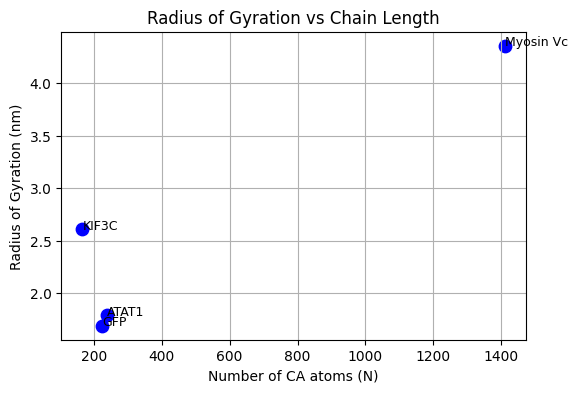

1ema.pdb: N = 225, Rg = 1.692 nm
5hmp.pdb: N = 1411, Rg = 4.357 nm
4b5o.pdb: N = 238, Rg = 1.794 nm
5jvm.pdb: N = 166, Rg = 2.610 nm


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Path where PDB files were downloaded
pdb_folder = "./Pdb_files"

def read_ca_coordinates(pdb_file):
    """
    Reads C-alpha (CA) atom coordinates from a PDB file.
    """
    coords = []
    with open(pdb_file, 'r') as f:
        for line in f:
            if line.startswith(("ATOM", "HETATM")) and line[12:16].strip() == "CA":
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                coords.append([x, y, z])
    return np.array(coords)

def calculate_center_of_mass(coords):
    return np.mean(coords, axis=0)

def calculate_radius_of_gyration(coords):
    R_cm = calculate_center_of_mass(coords)
    squared_distances = np.sum((coords - R_cm)**2, axis=1)
    Rg_angstrom = np.sqrt(np.mean(squared_distances))
    return Rg_angstrom / 10  # convert Å to nm

# List of PDB files with full paths
pdb_files = [
    os.path.join(pdb_folder, "1ema.pdb"),
    os.path.join(pdb_folder, "5hmp.pdb"),
    os.path.join(pdb_folder, "4b5o.pdb"),
    os.path.join(pdb_folder, "5jvm.pdb")
]

# Labels for proteins (your mapping)
protein_names = ["GFP", "Myosin Vc", "ATAT1", "KIF3C"]

Rg_values = []
N_values = []
dataset = {"pdb_file": [], "Name": [], "Radius of Gyration (nm)": [], "No. of amino acids": []}

for pdb_file, name in zip(pdb_files, protein_names):
    coords = read_ca_coordinates(pdb_file)
    Rg = calculate_radius_of_gyration(coords)
    Rg_values.append(Rg)
    N_values.append(len(coords))
    dataset["pdb_file"].append(os.path.basename(pdb_file))
    dataset["Name"].append(name)
    dataset["Radius of Gyration (nm)"].append(Rg)
    dataset["No. of amino acids"].append(len(coords))

df = pd.DataFrame(dataset)
df.index += 1

display(df)

# Plot RG vs N
plt.figure(figsize=(6,4))
plt.scatter(N_values, Rg_values, s=80, c="blue")
for i, name in enumerate(protein_names):
    plt.text(N_values[i]+1, Rg_values[i], name, fontsize=9)
plt.xlabel("Number of CA atoms (N)")
plt.ylabel("Radius of Gyration (nm)")
plt.title("Radius of Gyration vs Chain Length")
plt.grid(True)
plt.show()

# Print results
for pdb_file, N, Rg in zip(dataset["pdb_file"], N_values, Rg_values):
    print(f"{pdb_file}: N = {N}, Rg = {Rg:.3f} nm")
